# Aggregation Level and Match Analysis: Modeling

This notebook demonstrates how the **aggregation level** at which football (soccer) event data are analysed changes the estimated associations between performance indicators (PIs) and match success — a form of *confounding* described in the accompanying manuscript.

## Data

**StatsBomb open data** — 1. Bundesliga 2015/16 season, 306 matches, ≈ 600 000 events (loaded via [statsbombpy](https://github.com/statsbomb/statsbombpy)).


## Three Aggregation Levels — Overview

| Level | Unit | N (approx.) | Success criterion | Notes |
|-------|------|-------------|-------------------|-------|
| Season | Team × season | 18 | Rank category (0 = relegated, 3 = CL) | PIs summed over all 34 match-days |
| Match | Team × match | 612 | Match result (0 = away win, 1 = draw, 2 = home win) | PIs summed for full match |
| Scoreline | Team × scoreline segment | ~2 000 | Next goal (0 = away, 1 = none, 2 = home) | Normalised per-90 min; segments > 60 s only |

Each level fits an **ordered probit** model with a standardised PI difference as the sole predictor (plus match-status covariates at the scoreline level).

At the scoreline level, **match-status** covariates (home leading / away leading vs draw) are added to control for the systematic changes in team behaviour driven by the current score.

## Outcome Variables

| Level | Column | Values | Interpretation |
|-------|--------|--------|----------------|
| Season | `rank_category` | 0 (relegated) – 3 (Champions League) | Higher = better season outcome |
| Match | `match_outcome` | 0 (away win), 1 (draw), 2 (home win) | Home-team perspective |
| Scoreline | `next_goal` | 0 (away), 1 (none), 2 (home) | Which team scores next |

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import seaborn.objects as so
from statsbombpy import sb

In [14]:
# Make Jupyter store Matplotlib outputs as SVG (vector)
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')       # or: set_matplotlib_formats('svg', 'pdf')

# Optional: keep text as real text (not paths) in SVGs
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'


In [15]:
import statsmodels.api as sm
import scipy.stats as stats

from statsmodels.miscmodels.ordinal_model import OrderedModel

## Performance Indicators

The following 17 PIs are extracted from event data. At each aggregation level, the *difference* between the home and away team is computed.


In [16]:
cols = [
    'match_id', 'game_location', 'period', 'minute', 'second', 'timestamp', 'id', 'index', 'type', 'player', 'team', 'play_pattern', 'possession', 'possession_team',
    'under_pressure', 'tactics', 'duration', 'player_id', 'position', 'possession_team_id', 'team_id',
    'home_team', 'away_team', 'home_goals_ft', 'away_goals_ft', 'match_week',
    'dribble_outcome', 'duel_outcome', 'duel_type', 'location', 'pass_cross', 'pass_end_location', 
    'pass_height', 'pass_length', 'pass_outcome',  'pass_angle', 'pass_through_ball', 'pass_type', 
    'shot_outcome', 'shot_statsbomb_xg', 'shot_type'
]
performance_indicators = [
    'xg', 'shots',
    'passes', 'highpasses', 'groundpasses', 'pressuredpasses', 'pass_length',
    'crosses', 'dribbles', 
    'tackles', 'tackles_success', 'interceptions', 'pressures', 'blocks', 'fouls',
    'counterattacks',
    'passes_att3rd', 'passes_scorebox', 'vertical_passing_dist', 'actions_scorebox'

]

## Load Processed Data

In [ ]:
df_seasonlevel = pd.read_csv('data/df_seasonlevel.csv')
df_matchlevel = pd.read_csv('data/df_matchlevel.csv')
df_scorelinelevel = pd.read_csv('data/df_scorelinelevel.csv')

## Ordered Probit Model and Average Marginal Effects

We use an **ordered probit** model (latent-variable formulation with K−1 thresholds) from `statsmodels.miscmodels.ordinal_model.OrderedModel`. The predictor in all models is **`pi_diff`**: the home-minus-away standardised PI difference.

At the scoreline level, two **match-status** dummies (`match_status_away_leading`, `match_status_home_leading`, draw as reference) are added to control for the mechanical influence of the current score on team behaviour.

**Average Marginal Effects (AMEs)** give the average partial derivative of P(y = k) with respect to each predictor across all observations — a probability-scale interpretation of each coefficient.

In [18]:
from scipy.stats import norm
from scipy.special import expit
from scipy import stats as scipy_stats

def ordered_model_ame(fitted_model, X=None, colnames=None):
    """
    Average Marginal Effects (AMEs) for statsmodels OrderedModel.

    Parameters
    ----------
    fitted_model : OrderedModelResults
    X : array-like (n_obs, p). Defaults to fitted_model.model.exog.
    colnames : list[str]. Defaults to model exog_names.

    Returns
    -------
    pd.DataFrame (p, K): AME for each predictor and outcome category.
    """
    if X is None:
        X = fitted_model.model.exog
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n, p = X.shape
    K = fitted_model.model.k_levels
    params = np.asarray(fitted_model.params)
    beta = params[:p]
    taus = params[p:p + (K - 1)]
    if colnames is None:
        colnames = list(getattr(fitted_model.model, 'exog_names', [f'x{j}' for j in range(p)]))[:p]
    elif isinstance(colnames, str):
        colnames = [colnames]
    assert len(colnames) == p, 'Length of colnames must match number of predictors.'
    # statsmodels stores distr as a scipy.stats distribution object, not a string
    distr = fitted_model.model.distr
    if distr is scipy_stats.norm:
        f = norm.pdf
    elif distr is scipy_stats.logistic:
        f = lambda z: expit(z) * (1.0 - expit(z))
    else:
        raise ValueError("Unsupported distribution: expected scipy.stats.norm (probit) or scipy.stats.logistic (logit).")
    xb = X @ beta
    dP_dxb = np.zeros((n, K))
    dP_dxb[:, 0] = -f(taus[0] - xb)
    for k in range(1, K - 1):
        dP_dxb[:, k] = f(taus[k - 1] - xb) - f(taus[k] - xb)
    dP_dxb[:, K - 1] = f(taus[-1] - xb)
    ame = np.vstack([(dP_dxb * beta[j]).mean(axis=0) for j in range(p)])
    return pd.DataFrame(ame, index=colnames, columns=[f'P(y={k})' for k in range(K)])


## Running Models

For each performance indicator, we fit one ordered probit (and one ordered logit) model at each aggregation level. Probit coefficients, confidence intervals, and Average Marginal Effects are stored in `ls_dfs_coefs_probit`.

Loop structure:

1. **Season level** — `pi_diff` only; 4-category outcome (`rank_category`)
2. **Match level** — `pi_diff` only; 3-category outcome (match result)
3. **Scoreline level** — `pi_diff` + match-status dummies; 3-category outcome (next goal)

In [ ]:
ls_dfs_coefs_logit = []
ls_dfs_coefs_probit = []
for pi in performance_indicators:

    ls_levels = ['season_level', 'match_level', 'scoreline_level']
    ls_level_dfs = [df_seasonlevel, df_matchlevel, df_scorelinelevel]

    for level, level_df in zip(ls_levels, ls_level_dfs):
        if level == 'season_level':
            level_df['pi_diff'] = level_df[pi + '_diff']
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            predictors = ['pi_diff']
            X = level_df[predictors]
            y = level_df['outcome_ordered'].values

        elif level == 'match_level':
            level_df['pi_diff'] = level_df['home_' + pi] - level_df['away_' + pi]
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            predictors = ['pi_diff']
            X = level_df[predictors]
            y = level_df['outcome_ordered'].values

        elif level == 'scoreline_level':
            level_df['pi_diff'] = level_df['home_' + pi + '_90'] - level_df['away_' + pi + '_90']
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            dummies_matchstatus = pd.get_dummies(level_df['match_status'], prefix='match_status', drop_first=False).drop('match_status_draw', axis=1) * 1
            X = pd.concat([level_df[['pi_diff']], dummies_matchstatus], axis=1)
            y = level_df['outcome_ordered'].values

        mod_probit = OrderedModel(
            y, X, distr='probit'
        ).fit(method='bfgs', disp=False)

        mod_logit = OrderedModel(
            y, X, distr='logit'
        ).fit(method='bfgs', disp=False)

        # logit coefficients
        n_pred = X.shape[1]
        ci_logit = np.asarray(mod_logit.conf_int())
        df_coefs_logit = pd.DataFrame({
            'coefficients': np.asarray(mod_logit.params)[:n_pred],
            'confint_upper': ci_logit[:n_pred, 1],
            'confint_lower': ci_logit[:n_pred, 0],
        }, index=list(X.columns))
        df_coefs_logit['Odds Ratio'] = np.exp(df_coefs_logit['coefficients'])
        df_coefs_logit['indicator'] = pi
        df_coefs_logit['level'] = level
        ls_dfs_coefs_logit.append(df_coefs_logit)

        # probit coefficients + AMEs
        ci_probit = np.asarray(mod_probit.conf_int())
        df_coefs_probit = pd.DataFrame({
            'coefficients': np.asarray(mod_probit.params)[:n_pred],
            'confint_upper': ci_probit[:n_pred, 1],
            'confint_lower': ci_probit[:n_pred, 0],
        }, index=list(X.columns))
        ame_df = ordered_model_ame(mod_probit, X, colnames=list(X.columns))
        df_coefs_probit = pd.concat([df_coefs_probit, ame_df], axis=1)
        df_coefs_probit['indicator'] = pi
        df_coefs_probit['level'] = level
        ls_dfs_coefs_probit.append(df_coefs_probit)

In [48]:
df_coefs = pd.concat(ls_dfs_coefs_probit, axis=0).round(3).reset_index(names='param')


## Results

The coefficient plot below shows the probit coefficient for `pi_diff` (and its 95 % CI) at each aggregation level for each performance indicator. A positive coefficient indicates that outperforming the opponent on this PI is associated with a better outcome.

Coefficients that shift systematically across levels reveal **noncollapsibility**: the same PI–success association changes in magnitude or direction depending on temporal granularity.


In [49]:
df_coefs[~df_coefs['param'].isin(['match_status_away_leading', 'match_status_home_leading'])].drop('param', axis=1).set_index(['level', 'indicator']).unstack().sort_index(axis=1, level=1)

,P(y=0),P(y=1),P(y=2),P(y=3),coefficients,confint_lower,confint_upper,P(y=0),P(y=1),P(y=2),...,coefficients,confint_lower,confint_upper,P(y=0),P(y=1),P(y=2),P(y=3),coefficients,confint_lower,confint_upper
indicator,actions_scorebox,actions_scorebox,actions_scorebox,actions_scorebox,actions_scorebox,actions_scorebox,actions_scorebox,blocks,blocks,blocks,...,vertical_passing_dist,vertical_passing_dist,vertical_passing_dist,xg,xg,xg,xg,xg,xg,xg
level,,,,,,,,,,,,,,,,,,,,,
match_level,-0.052,0.001,0.051,NaN,0.146,0.015,0.278,0.007,-0.000,-0.006,...,0.233,0.099,0.367,-0.251,-0.021,0.271,NaN,0.897,0.709,1.084
possession_level,-0.023,-0.002,0.026,NaN,0.066,0.053,0.078,0.009,0.001,-0.010,...,0.033,0.020,0.045,-0.010,-0.001,0.011,NaN,0.029,0.017,0.042
scoreline_level,-0.152,-0.008,0.161,NaN,0.459,0.383,0.534,0.062,0.001,-0.063,...,0.395,0.322,0.468,-0.032,-0.001,0.033,NaN,0.090,0.020,0.160
season_level,-0.189,-0.057,-0.027,0.273,0.845,0.120,1.569,0.127,0.061,-0.006,...,1.016,0.286,1.746,-0.332,-0.052,-0.142,0.526,2.293,0.638,3.947


In [50]:
df_analysis = df_coefs[~df_coefs['param'].isin(['match_status_away_leading', 'match_status_home_leading'])].drop('param', axis=1).copy()

In [51]:
# At the season level the outcome has 4 categories (K=4), so P(y=3) is the top.
# At all other levels K=3, so P(y=2) is the top.
# ame_highest picks the appropriate column for each row.
df_analysis['ame_highest'] = df_analysis['P(y=3)'].fillna(df_analysis['P(y=2)'])

In [ ]:
df_coefs_export = (
    df_coefs[df_coefs['param'] == 'pi_diff']
    [['indicator', 'level', 'coefficients', 'confint_lower', 'confint_upper']]
    .reset_index(drop=True)
)
df_coefs_export.to_csv('data/df_coefs_probit.csv', index=False)

In [ ]:
ls_indicators_plot = [
    'xg', 'goals', 'shots',
      'passes', 'highpasses', 'groundpasses', 'pressuredpasses', 'crosses', 'dribbles',
    'pass_length', 'tackles', 'tackles_success',
    'interceptions',
      'pressures', 'blocks', 'fouls', 'counterattacks',
    'passes_att3rd', 'passes_scorebox', 'vertical_passing_dist', 'actions_scorebox',

]

names_indicators_plot = [
    'xG', 'Goals', 'Shots',
    'Passes', 'High Passes', 'Ground Passes', 'Pressured Passes', 'Crosses', 'Dribbles',
    'Pass Length', 'Tackles', 'Tackles Success',
    'Interceptions',
     'Pressures', 'Blocks', 'Fouls', 'Counterattacks',
         'Pass Att. Third', 'Passes to Scorebox', 'Vertical Passing Distance', 'Actionsin Scorebox',

]

df_plot = df_analysis.loc[
    df_analysis['indicator'].isin(ls_indicators_plot)
].copy()

df_plot['Indicator'] = df_plot['indicator'].map(dict(zip(ls_indicators_plot, names_indicators_plot)))

df_plot['Level'] = (
    df_plot['level']
    .str.replace('_level', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
    )

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import pandas as pd

# Create a fixed palette mapping for all possible Level values
def create_level_palette(df, col="Level"):
    unique_levels = sorted(df[col].unique())  # consistent order
    base_palette = sns.color_palette("colorblind", n_colors=len(unique_levels))
    return dict(zip(unique_levels, base_palette))

def plot_coefficients(df_plot, palette):
    # Clean up 'level' column for plotting
    df_plot = df_plot.copy()


    # ggplot-like theme
    sns.set_theme(style="whitegrid", font_scale=1.1)
    plt.rcParams.update({
        "axes.edgecolor": "0.8",
        "axes.linewidth": 0.8,
        "grid.color": "0.9",
        "grid.linestyle": "-",
        "axes.spines.top": False,
        "axes.spines.right": False
    })

    # Keep order for indicators
    df_plot["Indicator"] = pd.Categorical(
        df_plot["Indicator"],
        ordered=True,
        categories=df_plot["Indicator"].unique()
    )

    # Build plot
    p = (
        so.Plot(
            df_plot,
            x="Indicator",
            y="coefficients",
            color="Level",
            ymin="confint_lower",
            ymax="confint_upper"
        )
        .scale(color=palette)   # FIXED PALETTE HERE
        .add(so.Range(), so.Dodge())
        .add(so.Dot(), so.Dodge())
        .label(x="Indicator", y="Coefficient", color="Level")
    )

    fig = plt.figure(figsize=(13, 5))
    p.on(fig).plot()
    plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Performance Indicator")
    plt.ylabel("Coefficient [95% CI]")
    plt.grid(True, linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()


In [55]:
def plot_ame(df_plot, palette):
    df_plot = df_plot.copy()

    sns.set_theme(style="whitegrid", font_scale=1.1)
    plt.rcParams.update({
        "axes.edgecolor": "0.8",
        "axes.linewidth": 0.8,
        "grid.color": "0.9",
        "grid.linestyle": "-",
        "axes.spines.top": False,
        "axes.spines.right": False
    })

    df_plot["Indicator"] = pd.Categorical(
        df_plot["Indicator"],
        ordered=True,
        categories=df_plot["Indicator"].unique()
    )

    p = (
        so.Plot(df_plot, x="Indicator", y="ame_highest", color="Level")
        .scale(color=palette)
        .add(so.Dot(), so.Dodge())
        .label(x="Indicator", y="AME on P(y=highest)", color="Level")
    )

    fig = plt.figure(figsize=(13, 5))
    p.on(fig).plot()
    plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Performance Indicator")
    plt.ylabel("AME on P(y=highest) [pp]")
    plt.grid(True, linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()

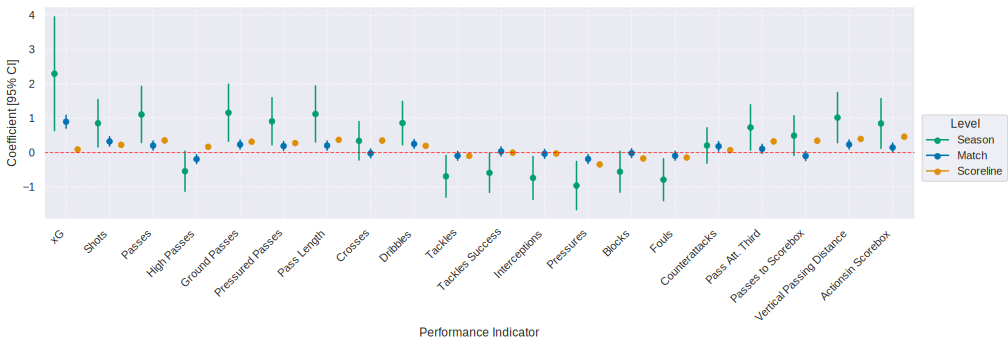

In [56]:
#| label: fig-coefficients-season
#| fig-cap: "Coefficients of Probit Model for Performance Indicators Across Aggregation Levels"
#| fig-width: 
#| fig-height: 4

full_palette = create_level_palette(df_plot)

# Plot all levels
plot_coefficients(df_plot, full_palette)

# Plot excluding one level, but colors stay consistent


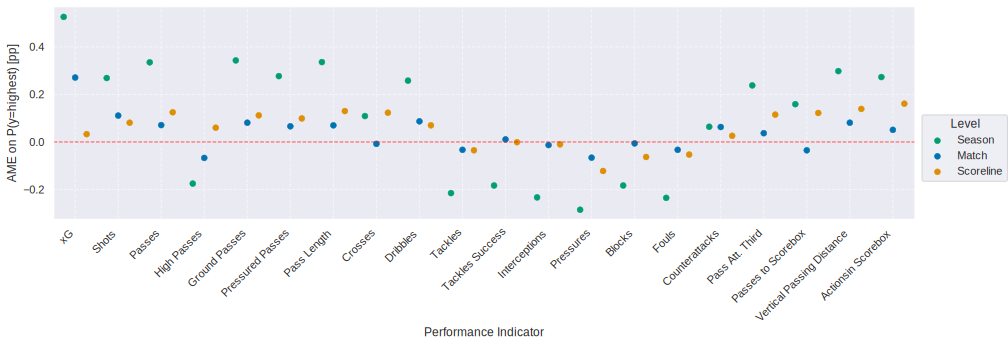

In [57]:
#| label: fig-ame-season
#| fig-cap: "AME on P(y=highest) for Performance Indicators Across Aggregation Levels"
#| fig-width: 
#| fig-height: 4

plot_ame(df_plot, full_palette)

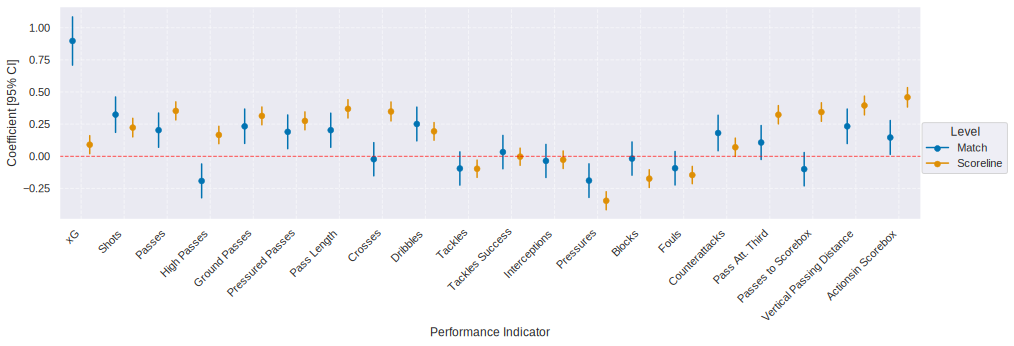

In [58]:
#| label: fig-coefficients-noseason
#| fig-cap: "Coefficients of Probit Model for Performance Indicators Across Aggregation Levels"
#| fig-width: 5
#| fig-height: 4
df_plot_noseason = df_plot[df_plot.level != 'season_level'].copy()

plot_coefficients(df_plot_noseason, full_palette)

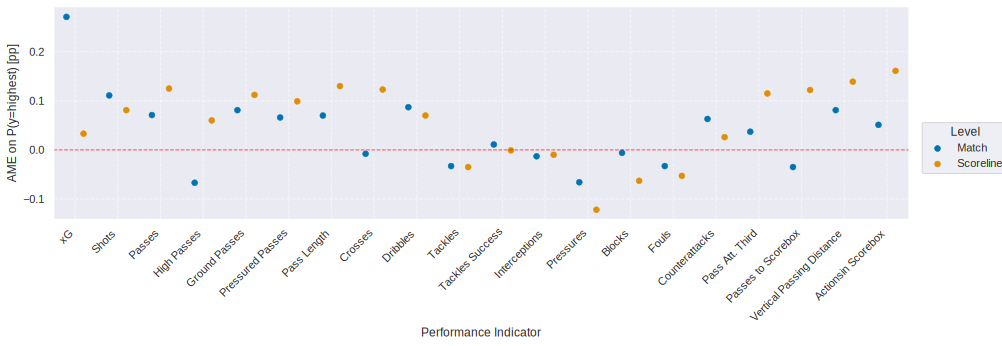

In [59]:
#| label: fig-ame-noseason
#| fig-cap: "AME on P(y=highest) for Performance Indicators Across Aggregation Levels (Excluding Season)"
#| fig-width: 5
#| fig-height: 4

plot_ame(df_plot_noseason, full_palette)

### Effect of Match Status on Behaviour

The table below shows the mean home-minus-away PI difference by match-status category. Teams that are *leading* tend to play differently from teams that are *drawing* or *trailing* — this is why match-status dummies are included as covariates at the scoreline and possession levels.


In [51]:
#| label: tbl-indicators-scoreline
#| tbl-cap: Means of Performance Indicators with Respect to Match Status

ls_dfs_context = []
for pi in ls_indicators_plot:
    if pi != 'goals':
        df_scorelinelevel[pi + '_diff'] = df_scorelinelevel['home_' + pi] - df_scorelinelevel['away_' + pi]
        ls_dfs_context.append(df_scorelinelevel.groupby('match_status')[pi + '_diff'].mean().round(2))

df_context = pd.concat(ls_dfs_context, axis=1)
df_context.columns = df_context.columns.str.replace('_diff', '').map(dict(zip(ls_indicators_plot, names_indicators_plot)))

df_context.index.name = 'Match Status'
df_context.index = df_context.index.map({
    'away_leading': 'Away Leading',
    'draw': 'Draw',
    'home_leading': 'Home Leading'
})

df_context

/tmp/ipykernel_33947/1494265107.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_scorelinelevel[pi + '_diff'] = df_scorelinelevel['home_' + pi] - df_scorelinelevel['away_' + pi]


,xG,Shots,Passes,High Passes,Ground Passes,Pressured Passes,Crosses,Dribbles,Pass Length,Tackles,Tackles Success,Interceptions,Pressures,Blocks,Fouls,Counterattacks,Pass Att. Third,Passes to Scorebox,Vertical Passing Distance,Actionsin Scorebox
Match Status,,,,,,,,,,,,,,,,,,,,
Away Leading,-0.20,0.34,16.59,1.97,11.40,0.27,1.61,-0.01,283.82,-0.03,-0.01,-0.34,-1.07,-0.98,-0.17,-0.67,3.27,4.13,23.82,6.88
Draw,0.06,0.72,14.21,0.67,12.65,-0.09,0.98,0.54,270.49,-0.16,-0.07,-0.21,-1.50,-0.18,-0.38,-0.24,1.67,2.04,35.17,5.17
Home Leading,0.30,0.79,-5.01,-0.53,-2.98,-0.40,-0.42,-0.16,-94.98,0.40,0.30,0.31,1.67,0.24,0.05,0.95,-0.53,-1.09,-3.15,0.60


### Effect of Context (Scoreline) on Success (Probability of Next Goal)

* Calculate baserates of next goal (marginal distribution of next goal), then
* Calculate proportions for the three levels of match status (conditional distribution of next goal on match status)

In [125]:
df_context_nextgoal = df_scorelinelevel[['match_status', 'next_goal']].value_counts().unstack()

In [128]:
df_nextgoal_baseline = pd.DataFrame(df_scorelinelevel['next_goal'].value_counts().round(3)).T

df_nextgoal_baseline.columns.name = None

df_nextgoal_baseline.columns = df_nextgoal_baseline.columns.map({
    'away': 'Next Goal: Away',
    'none': 'Next Goal: None',
    'home': 'Next Goal: Home'
})

df_nextgoal_baseline.index = ['Total']

df_nextgoal_baseline_pct = df_nextgoal_baseline.div(df_nextgoal_baseline.sum(axis=1), axis=0).round(3) * 100

In [129]:
df_context_nextgoal.index.name = "Match Status"
df_context_nextgoal.columns.name = None

df_context_nextgoal.columns = df_context_nextgoal.columns.map({
    'away': 'Next Goal: Away',
    'none': 'Next Goal: None',
    'home': 'Next Goal: Home'
})

df_context_nextgoal.index = df_context_nextgoal.index.map({
    'away_leading': 'Away Leading',
    'draw': 'Draw',
    'home_leading': 'Home Leading'
})

df_context_nextgoal = df_context_nextgoal.sort_index().sort_index(axis=1)

df_context_nextgoal = pd.concat([df_context_nextgoal, df_nextgoal_baseline], axis=0)

df_context_nextgoal_pct = df_context_nextgoal.div(df_context_nextgoal.sum(axis=1), axis=0).round(3) * 100

In [130]:
#| label: tbl-nextgoal-scoreline
#| tbl-cap: Distribution of next goal with respect to match status
 
df_context_nextgoal

,Next Goal: Away,Next Goal: Home,Next Goal: None
Away Leading,103,95,97
Draw,167,206,69
Home Leading,115,174,130
Total,385,475,296


In [131]:
#| label: tbl-nextgoal-scoreline-pct
#| tbl-cap: Relative frequencies of next goals with respect to match status

df_context_nextgoal_pct

,Next Goal: Away,Next Goal: Home,Next Goal: None
Away Leading,34.9,32.2,32.9
Draw,37.8,46.6,15.6
Home Leading,27.4,41.5,31.0
Total,33.3,41.1,25.6


In [133]:
#| label: tbl-nextgoal-combined
#| tbl-cap: "Distribution of next goal with respect to match status (absolute counts with row percentages in parentheses)"

df_combined = df_context_nextgoal.copy().astype(str)
for col in df_context_nextgoal.columns:
    for idx in df_context_nextgoal.index:
        n = df_context_nextgoal.loc[idx, col]
        pct = df_context_nextgoal_pct.loc[idx, col]
        df_combined.loc[idx, col] = f"{int(n)} ({pct:.1f}%)"

df_combined

,Next Goal: Away,Next Goal: Home,Next Goal: None
Away Leading,103 (34.9%),95 (32.2%),97 (32.9%)
Draw,167 (37.8%),206 (46.6%),69 (15.6%)
Home Leading,115 (27.4%),174 (41.5%),130 (31.0%)
Total,385 (33.3%),475 (41.1%),296 (25.6%)


### Statistical Test of the Effect of Scoreline on Success

**Chi-Squared Test: Match Status and Next-Goal Distribution**

To motivate the inclusion of match status as a covariate in the scoreline- and possession-level models, we test whether the distribution of next-goal outcomes differs across match-status categories. Specifically, we ask: does the probability that the home team, the away team, or neither team scores next depend on whether the home team is currently leading, trailing, or level?

We use a chi-squared test of independence on the contingency table of match status × next goal. The null hypothesis is that the next-goal distribution is the same in all three match-status groups — i.e., equal to the overall marginal distribution. Rejecting this null provides direct empirical justification for treating match status as a confound that must be controlled.

#### Expected Counts (under marginal distribution of next goals)

In [ ]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_scorelinelevel['match_status'], df_scorelinelevel['next_goal'])
chi2_stat, p_val, dof, expected = chi2_contingency(ct)

df_expected_counts = pd.DataFrame(expected.round(1), index=ct.index, columns=ct.columns)

df_expected_counts.index.name = "Match Status"
df_expected_counts.columns.name = None

df_expected_counts.columns = df_expected_counts.columns.map({
    'away': 'Next Goal: Away',
    'none': 'Next Goal: None',
    'home': 'Next Goal: Home'
})

df_expected_counts.index = df_expected_counts.index.map({
    'away_leading': 'Away Leading',
    'draw': 'Draw',
    'home_leading': 'Home Leading'
})

df_expected_counts

,Next Goal: Away,Next Goal: Home,Next Goal: None
Match Status,,,
Away Leading,98.2,121.2,75.5
Draw,147.2,181.6,113.2
Home Leading,139.5,172.2,107.3


#### Observed Counts

In [ ]:
df_observed_counts = pd.DataFrame(ct.values, index=ct.index, columns=ct.columns)

df_observed_counts.index.name = "Match Status"
df_observed_counts.columns.name = None

df_observed_counts.columns = df_observed_counts.columns.map({
    'away': 'Next Goal: Away',
    'none': 'Next Goal: None',
    'home': 'Next Goal: Home'
})

df_observed_counts.index = df_observed_counts.index.map({
    'away_leading': 'Away Leading',
    'draw': 'Draw',
    
    'home_leading': 'Home Leading'
})

df_observed_counts

,Next Goal: Away,Next Goal: Home,Next Goal: None
Match Status,,,
Away Leading,103,95,97
Draw,167,206,69
Home Leading,115,174,130


#### Chi-Squared Test

In [142]:
print(f"Chi-squared test: next_goal distribution by match_status vs. marginal")
print(f"  χ²({dof}) = {chi2_stat:.3f}, p = {p_val:.4g}")

Chi-squared test: next_goal distribution by match_status vs. marginal
  χ²(4) = 44.322, p = 5.499e-09


The test yields a statistically significant result, indicating that the next-goal distribution varies systematically with match status. Teams that are currently leading or trailing do not face the same scoring probabilities as teams in a draw situation — the current scoreline shapes which team is more likely to score next. This confirms that match status is a genuine confound at the scoreline level: any association between a performance indicator and next-goal outcome is partly driven by the score context in which the actions occur, rather than by the indicator alone.

## Selected Indicators for Paper

The following cells render figures and a table for four selected indicators only (shots, passes, high passes, crosses), for inclusion in the manuscript. Full results for all indicators are in the cells above.

In [24]:
selected_indicators_plot = ['shots', 'passes', 'highpasses', 'passes_scorebox']
selected_names_indicators_plot = ['Shots', 'Passes', 'High Passes', 'Passes to Scorebox']

df_plot_selected = df_plot[df_plot['indicator'].isin(selected_indicators_plot)].copy()
df_plot_selected['Indicator'] = pd.Categorical(
    df_plot_selected['Indicator'],
    ordered=True,
    categories=selected_names_indicators_plot
)

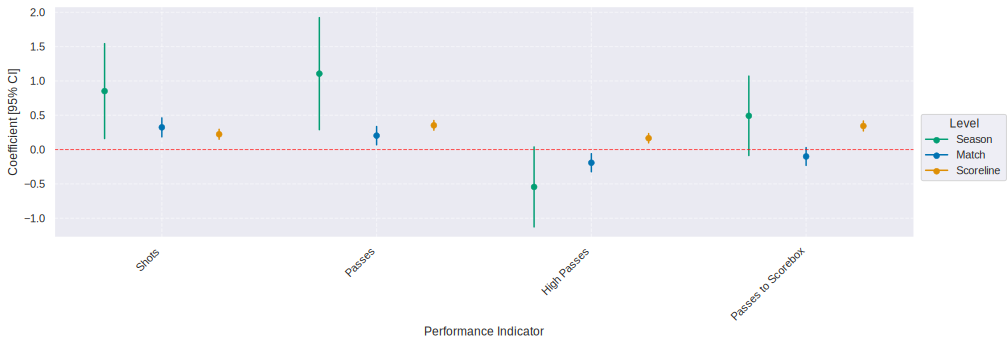

In [25]:
#| label: fig-coefficients-season-selected
#| fig-cap: "Probit Model Coefficients for Selected Performance Indicators Across Aggregation Levels"
#| fig-width: 7
#| fig-height: 4

plot_coefficients(df_plot_selected, full_palette)

In [ ]:
#| label: fig-ame-season-selected
#| fig-cap: "AME on P(y=highest) for Selected Performance Indicators Across Aggregation Levels"
#| fig-width: 7
#| fig-height: 4

plot_ame(df_plot_selected, full_palette)

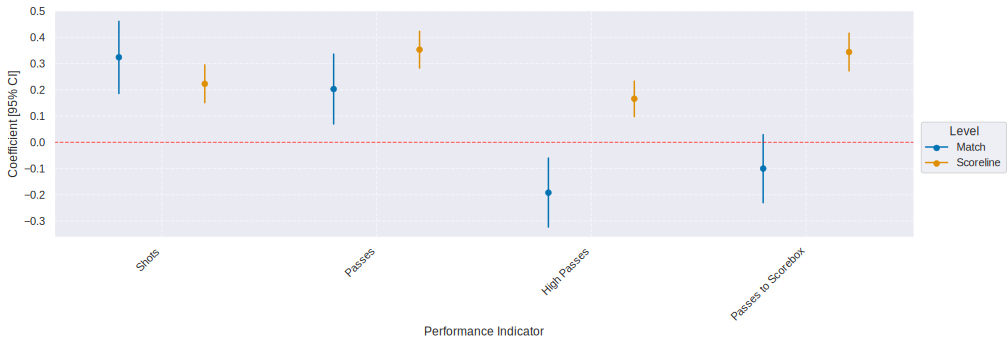

In [26]:
#| label: fig-coefficients-noseason-selected
#| fig-cap: "Probit Model Coefficients for Selected Performance Indicators at Match and Scoreline Levels"
#| fig-width: 7
#| fig-height: 4

df_plot_selected_noseason = df_plot_selected[df_plot_selected['level'] != 'season_level'].copy()
plot_coefficients(df_plot_selected_noseason, full_palette)

In [ ]:
#| label: fig-ame-noseason-selected
#| fig-cap: "AME on P(y=highest) for Selected Performance Indicators at Match and Scoreline Levels"
#| fig-width: 7
#| fig-height: 4

df_plot_selected_noseason_ame = df_plot_selected[df_plot_selected['level'] != 'season_level'].copy()
plot_ame(df_plot_selected_noseason_ame, full_palette)

In [27]:
#| label: tbl-indicators-scoreline-selected
#| tbl-cap: "Mean Home-minus-Away Differential of Selected Performance Indicators by Match Status"

df_context[selected_names_indicators_plot]

,Shots,Passes,High Passes,Passes to Scorebox
Match Status,,,,
Away Leading,0.34,16.59,1.97,4.13
Draw,0.72,14.21,0.67,2.04
Home Leading,0.79,-5.01,-0.53,-1.09


### Statistical Tests of the Effect of Context

In [70]:
df_scorelinelevel

,match_id,scoreline_id,home_score,away_score,scoreline,match_status,next_goal,home_team,away_team,home_goals_ft,...,tackles_success_diff,interceptions_diff,pressures_diff,blocks_diff,fouls_diff,counterattacks_diff,passes_att3rd_diff,passes_scorebox_diff,vertical_passing_dist_diff,actions_scorebox_diff
0,3890259,1,0,0,0,draw,home,Bayern Munich,Hamburger SV,5,...,0.0,-1.0,-35.0,-2.0,1.0,1.0,14.0,6.0,385.0,10.0
1,3890259,2,1,0,1,home_leading,home,Bayern Munich,Hamburger SV,5,...,-1.0,0.0,-37.0,0.0,-7.0,8.0,13.0,11.0,321.7,29.0
2,3890259,3,2,0,2,home_leading,home,Bayern Munich,Hamburger SV,5,...,-1.0,-1.0,-46.0,-2.0,0.0,-1.0,8.0,3.0,85.9,23.0
3,3890259,4,3,0,3,home_leading,home,Bayern Munich,Hamburger SV,5,...,-1.0,0.0,-4.0,-1.0,0.0,6.0,1.0,3.0,37.9,10.0
4,3890259,5,4,0,4,home_leading,home,Bayern Munich,Hamburger SV,5,...,0.0,-2.0,-25.0,1.0,2.0,-5.0,11.0,5.0,141.9,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,3890564,1,0,0,0,draw,home,Augsburg,Hamburger SV,1,...,0.0,-1.0,-1.0,0.0,-2.0,0.0,-1.0,1.0,124.1,8.0
1152,3890564,2,1,0,1,home_leading,away,Augsburg,Hamburger SV,1,...,0.0,-2.0,9.0,1.0,-1.0,-4.0,-7.0,-3.0,35.1,-2.0
1153,3890564,3,1,1,0,draw,away,Augsburg,Hamburger SV,1,...,-3.0,-3.0,21.0,2.0,-1.0,6.0,0.0,-7.0,-201.4,-11.0
1154,3890564,4,1,2,-1,away_leading,away,Augsburg,Hamburger SV,1,...,-1.0,-1.0,-22.0,1.0,-2.0,0.0,8.0,5.0,271.3,1.0


In [ ]:
df_scorelinelevel['home_highpasses']

In [ ]:
import statsmodels.formula.api as smf

rows = []
for pi in selected_indicators_plot:
    dep_var = pi + '_diff'
    formula = f'{dep_var} ~ C(match_status, Treatment(reference="draw"))'
    results = smf.ols(formula, data=df_scorelinelevel).fit()

    ci = results.conf_int()
    r2 = results.rsquared
    fval = results.fvalue
    fpval = results.f_pvalue

    for param in results.params.index:
        if param == 'Intercept':
            continue
        # Extract the match_status level name from the parameter label
        level = param.split('[T.')[-1].rstrip(']')
        rows.append({
            'indicator': pi,
            'match_status': level,
            'coef': results.params[param],
            'ci_lower': ci.loc[param, 0],
            'ci_upper': ci.loc[param, 1],
            't': results.tvalues[param],
            'p': results.pvalues[param],
            'r2': r2,
            'f': fval,
            'f_p': fpval,
        })

df_ols_matchstatus = pd.DataFrame(rows).round(4)
df_ols_matchstatus